# Residual networks and neural ODEs

*Introduction to Control and Machine Learning · Part IV: Fusion · Notebook 13*

> **Central question.** *When is a residual network a discretized controlled ODE, and how does the adjoint method of control compute its gradient exactly?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 90–110 min · DEEPER LOOK and RESEARCH WINDOW ≈ 25 min more |
| **Execution time** | a few seconds |
| **Exercises** | 6 exercises, ≈ 100–150 min |
| **Prerequisites** | [notebook 07](07_adjoints_density_heat_control.ipynb) (the adjoint method, §2), [notebook 12](12_shallow_networks_representation_sparsity.ipynb) (a neuron $w\,\sigma(a\cdot x+b)$), [notebook 11](11_optimization_algorithms_ml.ipynb) (Adam), [notebook 09](09_machine_learning_foundations_generalization.ipynb) (the protocol); helpful: [notebook 08](08_long_time_control_turnpike.ipynb) (long horizons) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 53, 193–196, 325–332, 336–339, 354, 359, 362 (see the Source map at the end) |
| **Notation** | `notation.md` §5. $\Theta$ is the full parameter set; $\theta_k=(W_k,A_k,b_k)$ the parameters of layer $k$. **From this notebook on, $w$ (a column of $W$) is the outer weight of a neuron of the vector field**, as on p. 327, not the outer weight $\omega_j$ of notebook 12 nor the parameter vector of notebooks 09–11. **Two meanings of $L$:** the slides write $L$ for the number of layers or switches (pp. 350, 355), and $L$ is also the usual name of a Lipschitz constant. Here the number of layers is $K$ and the Lipschitz constant of the field is $L_f$ |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–6 (the residual network as an Euler scheme; the error of Euler's method at a fixed horizon; training as simultaneous optimal control; the discrete adjoint; the E6 classifier), Figures 1–3, Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §8 (the continuous adjoint and why it is not the gradient of the discrete cost; order preservation in one dimension), Exercises 3–4.
> *Research-oriented:* the RESEARCH WINDOW §9 (turnpike and momentum) and the `ADVANCED` Exercises 5–6.

**Learning objectives.** After this notebook you should be able to

1. write a residual network as the forward Euler scheme of a controlled ODE, and distinguish refining the step at a fixed horizon from extending the horizon at a fixed step;
2. state the hypotheses under which Euler's method converges at order one, and measure the order on nested meshes;
3. write the training of a residual network as a simultaneous optimal control problem, with sample averages and regularization in the right places;
4. derive the discrete adjoint recursion and the parameter gradient, and verify them against central differences;
5. count the cost of a gradient in field and Jacobian evaluations;
6. train a small residual classifier with a validation-based choice, and say what has, and has not, been evaluated.

## Where are we?
`CORE`

> **Recap.** [Notebook 07](07_adjoints_density_heat_control.ipynb), §2: one state solve forward, one adjoint solve backward, and their combination give the whole gradient of a cost, whatever the number of controls. [Notebook 12](12_shallow_networks_representation_sparsity.ipynb): a neuron $w\,\sigma(a\cdot x+b)$, and networks that are linear in some parameters and nonlinear in others.

The slides open the Fusion part with three formulas side by side (p. 327): a **neural ODE** $x'(t)=w(t)\,\sigma(a(t)\cdot x(t)+b(t))$, its Euler discretization $x_{k+1}=x_k+h\,w_k\sigma(a_k\cdot x_k+b_k)$, and the shallow network $\sum_jw_j\sigma(a_j\cdot x+b_j)$ of notebook 12. This notebook studies the first two and the bridge between them. The data point becomes an **initial state**, the network's parameters become a **control**, and a forward pass becomes a **trajectory**. Once training is written as an optimal control problem, the adjoint method of notebook 07 computes its gradient, and it turns out to be exactly backpropagation.

## 1. A residual network is an Euler scheme
`CORE`

**The vector field.** A neuron in $\mathbb R^d$ is $w\,\sigma(a\cdot x+b)$, with outer weight $w\in\mathbb R^d$ (the direction of the field), inner weight $a\in\mathbb R^d$ and bias $b\in\mathbb R$. With $P$ neurons,
$$
f(x,\theta)=\sum_{j=1}^Pw_j\,\sigma(a_j\cdot x+b_j)=W\sigma(Ax+b),\qquad\theta=(W,A,b),
$$
where the columns of $W\in\mathbb R^{d\times P}$ are the $w_j$, the rows of $A\in\mathbb R^{P\times d}$ are the $a_j$, and $\sigma$ acts entrywise. With $P=1$ this is the field of p. 327. In this notebook $\sigma=\tanh$ unless stated, because the gradient checks of §4 need a differentiable field; the ReLU appears in notebook 14.

**The neural ODE and its Euler scheme.** For a control $t\mapsto\theta(t)$ on $[0,T]$ and an input $x_0$,
$$
x'(t)=f(x(t),\theta(t)),\quad x(0)=x_0;\qquad\qquad x_{k+1}=x_k+h\,f(x_k,\theta_k),\quad k=0,\dots,K-1,\quad T=Kh.
$$
The second formula is a **residual network** (ResNet) with $K$ layers: each layer adds a correction to its input instead of replacing it. Residual networks made it possible to train much deeper networks than before (He et al., 2016; p. 53), and the reading of their layers as time steps of an ODE is the starting point of this part of the course (p. 337). The map $x_0\mapsto x_K$ approximates the **flow map** $\Phi_T:x_0\mapsto x(T)$ (p. 339). A control that is constant on each layer and jumps between layers is piecewise constant: *each time discontinuity is one change of layer* (p. 339).

**Two ways to add layers.** The formula $T=Kh$ hides a choice.

- **Refinement at a fixed horizon:** $K\to2K$, $h\to h/2$, with the new layers sampling the *same* control $\theta(t)$. The network approximates one fixed flow map $\Phi_T$ better and better (§2). This is the sense in which a deep ResNet "is" a neural ODE.
- **A longer horizon at a fixed step:** $K\to2K$ with $h$ fixed, so $T\to2T$. The network now approximates a *different* map, the flow over a longer time. Errors are not reduced, and the error bound of §2 grows with $T$. This is the long-horizon reading of notebook 08.

A trained ResNet need not be either: nothing forces its layer parameters $\theta_k$ to vary regularly with $k$. The ODE reading is a modelling choice that becomes accurate when they do.

**At a fixed number of layers, $T$ is not a separate parameter.** In $x_{k+1}=x_k+(T/K)\,W_k\sigma(A_kx_k+b_k)$ only the products $(T/K)W_k$ appear: doubling $T$ and halving every $W_k$ gives the same network. The same holds for the ODE, by the change of time $s=t/T$. This is the remark of p. 338 that *the control time can be made arbitrarily small, absorbed into $\|w\|$ by scaling*. The time horizon matters only together with a bound on the size of the controls, for instance through a regularization term (§3).

> **Predict.** Take a fixed piecewise-constant control on $[0,2]$ and compute the Euler scheme with $h=\frac12,\frac14,\dots$, keeping the control fixed. By what factor should the error at $T=2$ shrink each time $h$ is halved? And if instead $h$ is fixed and the horizon is extended, what happens to the error?

## 2. The error of Euler's method at a fixed horizon
`CORE`

The statement below is classical; its proof is the standard one, written for the setting of this notebook *(pedagogical addition)*.

> **Proposition (global error of forward Euler).**
> *Assumptions:*
> - **(H1) Lipschitz in the state.** For every control value $\theta$ used, $|f(x,\theta)-f(y,\theta)|\le L_f|x-y|$ for all $x,y$. For $f=W\sigma(Ax+b)$ with $|\sigma'|\le1$ (true for $\tanh$ and for the ReLU), one can take $L_f=\max\|W\|\,\|A\|$ over the layers (spectral norms).
> - **(H2) Regularity in time.** The control is constant on each step $[t_k,t_{k+1})$; its discontinuities lie on mesh points.
> - $B$ bounds $|f|$ along the exact trajectory.
>
> *Conclusion:*
> $$|x_K-x(T)|\le\frac{Bh}{2}\big(e^{L_fT}-1\big).$$
>
> *Interpretation:* at a fixed horizon the error is $O(h)$, but the constant can grow exponentially with $T$.

*Proof.* On a step the field is autonomous, so the local error is
$$
\Big|x(t_{k+1})-x(t_k)-hf(x(t_k),\theta_k)\Big|=\Big|\int_{t_k}^{t_{k+1}}\!\big(f(x(s),\theta_k)-f(x(t_k),\theta_k)\big)ds\Big|\le L_fB\!\int_{t_k}^{t_{k+1}}\!(s-t_k)\,ds=\frac{L_fBh^2}{2},
$$
using $|x(s)-x(t_k)|\le B(s-t_k)$. The error $e_k=|x_k-x(t_k)|$ then satisfies $e_{k+1}\le(1+hL_f)e_k+\frac{L_fB}{2}h^2$ with $e_0=0$. Summing the geometric series, $e_K\le\frac{L_fBh^2}{2}\cdot\frac{(1+hL_f)^K-1}{hL_f}\le\frac{Bh}{2}(e^{L_fT}-1)$, because $1+hL_f\le e^{hL_f}$. $\square$

**About the hypotheses.**
- (H1) is what makes the network a well-posed flow. The ReLU satisfies it even though it is not differentiable: the proof uses only Lipschitz continuity.
- (H2) can be relaxed. If $t\mapsto f(x,\theta(t))$ is Lipschitz in time on each step, the local error gains a term proportional to that constant times $h^2$, and the order is still one.
- If a jump of the control falls *inside* a step, Euler uses the wrong field on part of that step, an error of order $h$ on that single step. With finitely many such jumps the global error is still $O(h)$, with a larger constant (the last lines printed by the laboratory check this). Higher-order methods, however, lose their order (Exercise 5). We keep the jumps on the mesh.
- The bound is a worst case. In the experiment we print it next to the observed error.

**Laboratory 1: one fixed field, nested meshes.** The control is chosen by hand, not trained. It has $P=2$ neurons and is constant on $M=4$ pieces of $[0,2]$. Halving $h$ means doubling the number of Euler steps per piece, so the jumps always lie on the mesh. The reference solution is computed by an adaptive high-order solver (`solve_ivp`, DOP853, tolerance $10^{-12}$), restarted at every jump, so it is independent of the scheme being tested.

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from src.ml_utils import make_streams, point_cloud_E6, split_indices
from src.node_utils import (field, euler_flow, piecewise_constant, sum_over_pieces, objective, discrete_adjoint,
                            continuous_adjoint_gradient, pack, half_plane_logistic, readout_label,
                            select_residual_classifier)
from src.plotting_utils import apply_style, COLORS, slope_guide

apply_style()
np.set_printoptions(precision=4, suppress=True)

# Identifiable streams (reports/protocol_12_16.md, section 13): "course" reproduces E6 and its split of notebooks
# 09-11; "dev" only provides random directions for the gradient checks. No final evaluation data are drawn here.
streams, stream_keys = make_streams(13, ["course", "dev"])
X6, y6 = point_cloud_E6(streams["course"])
train6, val6, test6 = split_indices(len(y6), streams["course"])   # the E6 test split was evaluated in 11: not used
print("stream keys:", stream_keys)

stream keys: {'course': ('course', 0), 'dev': (13, 6)}


L_f <= 1.957,  B <= 1.414
   K        h      error at T    error / h   observed order    bound of the Proposition
   4   0.50000     1.675e-01      0.3350                      1.734e+01
   8   0.25000     7.928e-02      0.3171            1.079     8.672e+00
  16   0.12500     3.877e-02      0.3102            1.032     4.336e+00
  32   0.06250     1.931e-02      0.3089            1.006     2.168e+00
  64   0.03125     9.694e-03      0.3102            0.994     1.084e+00
 128   0.01562     4.859e-03      0.3109            0.997     5.420e-01
 256   0.00781     2.432e-03      0.3113            0.998     2.710e-01
 512   0.00391     1.217e-03      0.3115            0.999     1.355e-01
1024   0.00195     6.086e-04      0.3116            1.000     6.775e-02
h = 0.050: error at T = 2, 4, 6, 8: [0.0155 0.0509 0.2258 0.5399]
h = 0.025: error at T = 2, 4, 6, 8: [0.0078 0.0252 0.1094 0.2885]
jumps inside steps, error / h for K = 62, 126, 254, 510: [1.5994 1.604  1.606  1.607 ]


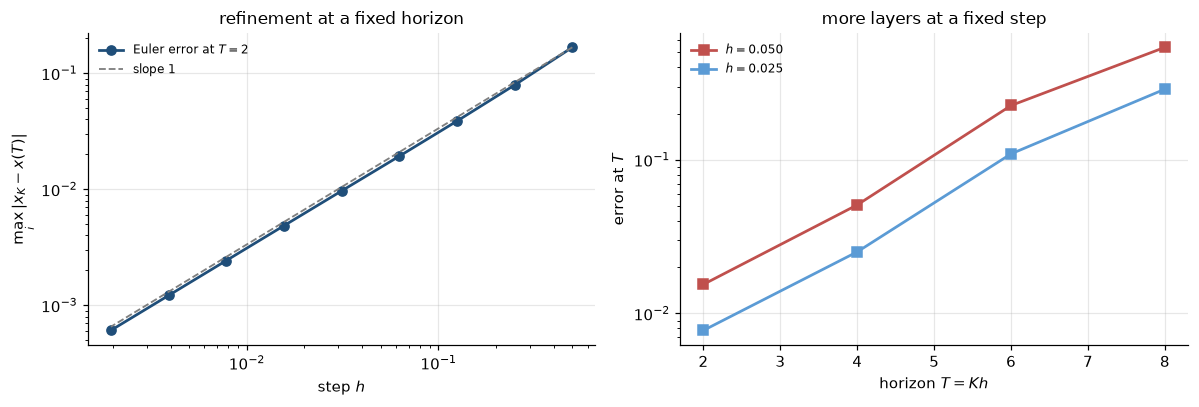

In [2]:
# A fixed, hand-chosen control, constant on M = 4 pieces of [0, 2]; width P = 2 in R^2, activation tanh.
M, T_fix = 4, 2.0
angles = np.pi * np.arange(M) / M
W_fix = np.stack([[[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]] for t in angles])         # (M, d, P)
A_fix = np.stack([(1 + 0.25 * m) * np.array([[1.0, 0.5], [-0.5, 1.0]]) for m in range(M)])     # (M, P, d)
b_fix = np.stack([(-1) ** m * np.array([0.2, -0.3]) for m in range(M)])                       # (M, P)
pieces_fix = (W_fix, A_fix, b_fix)
X_fix = 0.6 * np.column_stack([np.cos(np.arange(6) * np.pi / 3), np.sin(np.arange(6) * np.pi / 3)])


def reference_flow(X, pieces, piece_length):
    # Adaptive high-order solver, restarted at every jump of the control: independent of the Euler scheme.
    out = []
    for x in X:
        for W, A, b in zip(*pieces):
            x = solve_ivp(lambda t, z: field(z[None], W, A, b)[0], (0, piece_length), x,
                          method="DOP853", rtol=1e-12, atol=1e-13).y[:, -1]
        out.append(x)
    return np.array(out)


def euler_error(pieces, substeps, piece_length, X_ref):
    X_K = euler_flow(X_fix, piecewise_constant(pieces, substeps), piece_length / substeps)[-1]
    return np.linalg.norm(X_K - X_ref, axis=1).max()                  # worst case over the six inputs


x_ref = reference_flow(X_fix, pieces_fix, T_fix / M)
L_f = max(np.linalg.norm(W, 2) * np.linalg.norm(A, 2) for W, A in zip(W_fix, A_fix))
B = max(np.linalg.norm(W, 2) for W in W_fix) * np.sqrt(2)               # |W tanh(.)| <= ||W|| sqrt(P)
substeps = 2 ** np.arange(9)
h_fix = T_fix / (M * substeps)
err_fix = np.array([euler_error(pieces_fix, s, T_fix / M, x_ref) for s in substeps])
print(f"L_f <= {L_f:.3f},  B <= {B:.3f}")
print("   K        h      error at T    error / h   observed order    bound of the Proposition")
for k, (s, h, e) in enumerate(zip(substeps, h_fix, err_fix)):
    order = "" if k == 0 else f"{np.log2(err_fix[k - 1] / e):6.3f}"
    print(f"{M * s:4d}  {h:8.5f}  {e:12.3e}  {e / h:10.4f}   {order:>14s}    {B * h / 2 * np.expm1(L_f * T_fix):10.3e}")

# A longer horizon at a fixed step: the same four pieces repeated periodically, T = 2, 4, 6, 8.
horizons = np.array([2.0, 4.0, 6.0, 8.0])
periodic = {T: tuple(np.concatenate([p] * int(T / T_fix)) for p in pieces_fix) for T in horizons}
x_ref_long = {T: reference_flow(X_fix, periodic[T], T_fix / M) for T in horizons}
err_long = {T_fix / (M * s): [euler_error(periodic[T], s, T_fix / M, x_ref_long[T]) for T in horizons]
            for s in (10, 20)}                                         # h = 0.05 and h = 0.025
for h, errs in err_long.items():
    print(f"h = {h:.3f}: error at T = 2, 4, 6, 8:", np.array(errs))


def euler_misaligned(K):
    # K uniform steps on [0, 2] with K/4 not an integer: every jump of the control falls strictly inside a step.
    h, X = T_fix / K, X_fix.copy()
    for k in range(K):
        m = min(int(k * h / (T_fix / M) + 1e-12), M - 1)                # piece containing the left end of the step
        X = X + h * field(X, W_fix[m], A_fix[m], b_fix[m])
    return np.linalg.norm(X - x_ref, axis=1).max() / h


print("jumps inside steps, error / h for K = 62, 126, 254, 510:", np.array([euler_misaligned(K) for K in (62, 126, 254, 510)]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.loglog(h_fix, err_fix, "o-", color=COLORS["state"], label="Euler error at $T=2$")
slope_guide(ax1, h_fix, err_fix[0], 1, "slope 1")
ax1.set_xlabel("step $h$"); ax1.set_ylabel(r"$\max_i|x_K-x(T)|$"); ax1.legend(fontsize=8)
ax1.set_title("refinement at a fixed horizon")
for (h, errs), c in zip(err_long.items(), (COLORS["control"], COLORS["state2"])):
    ax2.semilogy(horizons, errs, "s-", color=c, label=f"$h={h:.3f}$")
ax2.set_xlabel("horizon $T=Kh$"); ax2.set_ylabel("error at $T$"); ax2.legend(fontsize=8)
ax2.set_title("more layers at a fixed step")
plt.tight_layout(); plt.show()

**Figure 1.** Forward Euler (a ResNet) for one fixed, hand-chosen piecewise-constant control, against an independent high-accuracy reference. *Left:* the worst error over six inputs at $T=2$, as $h$ is halved with the jumps of the control on the mesh, with a slope-1 guide. *Right:* the error at the final time when the same control is repeated periodically and layers are added at a fixed step, for two step sizes.

*Interpretation (answer to the prediction).* At a fixed horizon the error halves with $h$: the printed observed orders approach $1$ and the ratio error$/h$ settles near a constant, as the Proposition predicts. The printed bound is correct but pessimistic by about two orders of magnitude, because $e^{L_fT}$ is a worst case. When the jumps of the control fall inside steps (last printed line), error$/h$ still settles, at a larger value: the order survives, the constant does not. Adding layers at a fixed step does not reduce the error; it changes the map being approximated, and the error at the final time grows with the horizon, while halving $h$ still halves it at every $T$. "Deeper" means "more accurate" only in the first reading.

## 3. Training as simultaneous optimal control
`CORE`

Given data $\{(x^n,y^n)\}_{n=1}^N$, every input becomes an initial state, and **one** control $\Theta=(\theta_0,\dots,\theta_{K-1})$ must steer all $N$ trajectories at once. This is **simultaneous** (or ensemble) control, the slides' reading of supervised learning (p. 336): *"We will do it through simultaneous or ensemble control of Neural ODEs."* The slides write the standard training problem as (p. 328)
$$
\underbrace{\frac1N\sum_{n=1}^N\int_0^T\mathrm{loss}\big(x^n(t),y^n\big)\,dt}_{\text{empirical risk }E(x(\cdot))}\;+\;\alpha\int_0^T\|(a(t),w(t),b(t))\|^2\,dt .
$$
We use its Euler discretization, and allow a terminal cost as well (the loss at the output, the most common choice in practice):
$$
J(\Theta)=\frac1N\sum_{n=1}^N\Big[\Phi_n(x_K^n)+h\sum_{k=0}^{K-1}\ell_n(x_k^n)\Big]+\alpha h\sum_{k=0}^{K-1}|\theta_k|^2,\qquad x_{k+1}^n=x_k^n+hf(x_k^n,\theta_k),\ x_0^n=x^n .
$$
Here $|\theta_k|^2$ is the sum of the squares of all entries of $W_k,A_k,b_k$.

Two details decide whether a gradient computed for this cost is right.

- **The sample average.** The data terms are averaged over $n$, so their gradient is the average of per-sample gradients.
- **The regularization is added once.** It depends on $\Theta$ only, not on the sample. Placing it inside the per-sample sum *without* the average would count it $N$ times. A clean test of both: duplicating every sample must change neither $J$ nor its gradient (it is one of the tests of `src/node_utils.py`).

The regularization is a **control cost**, exactly as $\frac12\int|u|^2$ in notebooks 02–08: it prefers small controls, and it is what gives the horizon $T$ a meaning (§1). In machine-learning terms it is an **$L^2$ regularization of the parameters**. Added to the loss, as here, its gradient $2\alpha h\theta_k$ enters the gradient that Adam rescales; this is not the same as the *decoupled* weight decay of AdamW, which shrinks the parameters outside the adaptive rescaling. For plain gradient descent the two coincide up to the step size.

## 4. The discrete adjoint: backpropagation is the adjoint method
`CORE`

**Derivation** *(the discrete analogue of notebook 07, §2)*. Treat each Euler step as a constraint, with a multiplier $p_{k+1}^n\in\mathbb R^d$ for sample $n$ and step $k$:
$$
\mathscr L=J(\Theta)-\sum_{n=1}^N\sum_{k=0}^{K-1}p_{k+1}^n\cdot\big(x_{k+1}^n-x_k^n-hf(x_k^n,\theta_k)\big).
$$
On trajectories that satisfy the scheme, $\mathscr L=J$ for every choice of the multipliers. Choose them so that $\mathscr L$ does not depend, to first order, on the states. Setting the derivative with respect to $x_K^n$, then $x_k^n$, to zero gives
$$
p_K^n=\frac1N\nabla\Phi_n(x_K^n),\qquad p_k^n=\big(I+hD_xf(x_k^n,\theta_k)\big)^{\!\top}p_{k+1}^n+\frac hN\nabla\ell_n(x_k^n),\quad k=K-1,\dots,0,
$$
and what remains is the derivative with respect to the parameters:
$$
\boxed{\;\nabla_{\theta_k}J=h\sum_{n=1}^ND_\theta f(x_k^n,\theta_k)^{\top}p_{k+1}^n+2\alpha h\,\theta_k .\;}
$$
This is the general recursion $p_k=(I+hD_xf_k)^\top p_{k+1}+h\nabla_xr_k$, $\nabla_{\theta_k}J=hD_\theta f_k^\top p_{k+1}+h\nabla_\theta r_k$ for the running cost $r=\ell_n(x)+\alpha|\theta|^2$, with the average over samples placed in $p$ and the regularization counted once. It is an **exact** gradient of the discrete cost $J$, not an approximation: it is the chain rule, organized backward.

**For the neuron field** $f=W\sigma(z)$, $z=Ax+b$, all the products needed are explicit:
$$
D_xf^\top p=A^\top\big(\sigma'(z)\odot W^\top p\big),\qquad \nabla_W=p\,\sigma(z)^\top,\quad \nabla_A=\big(\sigma'(z)\odot W^\top p\big)x^\top,\quad \nabla_b=\sigma'(z)\odot W^\top p .
$$

**State, adjoint, gradient, once more.** The forward pass computes the states $x_k^n$ and stores them; the backward pass computes the adjoints $p_k^n$ from the output back to the input; the gradient combines them layer by layer. This is the structure of notebook 07 (pp. 193–196), and it is **backpropagation**: the slides recall that backpropagation (Werbos, 1974) is *equivalent to the chain rule and automatic differentiation in reverse accumulation mode* (p. 53). The by-product $p_0^n$ is the sensitivity of $J$ to the input $x^n$ itself.

**The cost of a gradient.** One forward pass costs $NK$ field evaluations, and one backward pass $NK$ vector–Jacobian products, each $O(dP)$ operations, i.e. about $N\times K\times P$ neuron evaluations each. The **number of passes**, one forward and one backward, does not depend on the number of parameters $|\Theta|=K(2dP+P)$; the work of each pass does depend on $N$, $K$, $P$ and $d$. A finite-difference gradient needs $2|\Theta|$ evaluations of $J$ (central differences), each one a forward pass. The functions of `src/node_utils.py` count both kinds of evaluation.

| Gradient by | forward passes | backward passes | exact? |
|---|---|---|---|
| central differences | $2|\Theta|$ | 0 | no: truncation $O(\varepsilon^2)$, rounding $O(\varepsilon_{\rm mach}/\varepsilon)$ |
| discrete adjoint | 1 | 1 | yes, up to rounding |

**Laboratory 2: the adjoint against central differences.** We check the gradient for the 72 E6 training points, the fixed control of Laboratory 1 with $K=8$ layers, and the label-dependent logistic loss used later in §5. Two costs are checked: (i) a terminal cost only; (ii) terminal cost, plus the same loss integrated along the trajectory as on p. 328, plus regularization $\alpha=0.01$. For three random directions $v$ (from the `dev` stream) we compare $\langle\nabla J,v\rangle$ with the central difference $\big(J(\Theta+\varepsilon v)-J(\Theta-\varepsilon v)\big)/2\varepsilon$.

> **Predict.** How should the relative discrepancy behave as $\varepsilon$ decreases from $10^{-1}$ to $10^{-10}$? Where should it be smallest, and how small?

terminal cost only                         smallest relative discrepancy per direction: 2.0e-11 (eps = 1e-06), 1.1e-10 (eps = 3e-06), 1.0e-11 (eps = 3e-06)
                                           adjoint gradient cost: 576 field evaluations + 576 vector-Jacobian products
terminal + integral cost + regularization  smallest relative discrepancy per direction: 3.2e-11 (eps = 3e-06), 8.2e-11 (eps = 3e-06), 2.6e-11 (eps = 1e-06)
                                           adjoint gradient cost: 576 field evaluations + 576 vector-Jacobian products
|Theta| = 80: a central-difference gradient needs 160 forward passes = 92160 field evaluations


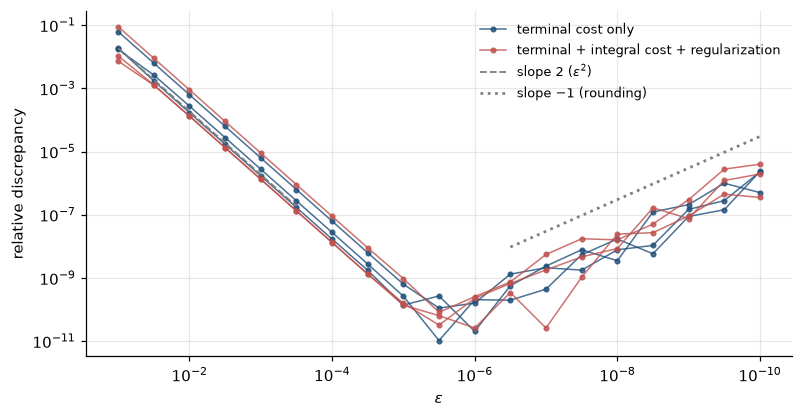

In [3]:
X_tr, y_tr, X_val, y_val = X6[train6], y6[train6], X6[val6], y6[val6]
Theta_chk, h_chk = piecewise_constant(pieces_fix, 2), T_fix / (2 * M)        # K = 8 layers of the fixed control
Phi, dPhi = half_plane_logistic(4.0)                                        # loss of label y at the state (see section 5)
costs = {"terminal cost only": (None, None, 0.0),
         "terminal + integral cost + regularization": (Phi(y_tr), dPhi(y_tr), 0.01)}
directions = [tuple(streams["dev"].normal(size=t.shape) for t in Theta_chk) for _ in range(3)]
eps_grid = np.logspace(-1, -10, 19)
check = {}
for name, (run, run_grad, alpha) in costs.items():
    counts = {}
    grad, _, _ = discrete_adjoint(X_tr, Theta_chk, h_chk, dPhi(y_tr), run_grad, alpha, counts=counts)
    J = lambda Th: objective(X_tr, Th, h_chk, Phi(y_tr), run, alpha)
    rel = np.zeros((len(directions), len(eps_grid)))
    for i, v in enumerate(directions):
        exact = sum(np.sum(g * d) for g, d in zip(grad, v))
        for j, e in enumerate(eps_grid):
            central = (J(tuple(t + e * d for t, d in zip(Theta_chk, v))) - J(tuple(t - e * d for t, d in zip(Theta_chk, v)))) / (2 * e)
            rel[i, j] = abs(central - exact) / abs(exact)
    check[name] = rel
    print(f"{name:42s} smallest relative discrepancy per direction: " + ", ".join(
        f"{r.min():.1e} (eps = {eps_grid[r.argmin()]:.0e})" for r in rel))
    print(f"{'':42s} adjoint gradient cost: {counts['field']} field evaluations + {counts['vjp']} vector-Jacobian products")
n_par = pack(Theta_chk).size
print(f"|Theta| = {n_par}: a central-difference gradient needs {2 * n_par} forward passes = "
      f"{2 * n_par * len(X_tr) * len(Theta_chk[2])} field evaluations")

fig, ax = plt.subplots(figsize=(7.4, 3.9))
for (name, rel), c in zip(check.items(), (COLORS["state"], COLORS["control"])):
    for i, r in enumerate(rel):
        ax.loglog(eps_grid, r, "o-", ms=3, lw=1, color=c, alpha=0.8, label=name if i == 0 else None)
slope_guide(ax, eps_grid[:6], check["terminal cost only"][0, 0], 2, r"slope 2 ($\varepsilon^2$)")
ax.loglog(eps_grid[-8:], 1e-16 / eps_grid[-8:] * 30, ":", color=COLORS["reference"], label=r"slope $-1$ (rounding)")
ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("relative discrepancy"); ax.invert_xaxis(); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Figure 2.** The discrete adjoint against central differences on the E6 training points, for the two costs, along three random directions each: relative discrepancy between $\langle\nabla J,v\rangle$ and $\big(J(\Theta+\varepsilon v)-J(\Theta-\varepsilon v)\big)/2\varepsilon$ as $\varepsilon$ decreases (left to right), with guides of slopes $2$ and $-1$.

*Interpretation (answer to the prediction).* The curves have the V shape of notebook 07. For large $\varepsilon$ the discrepancy is the truncation error of the central difference, decreasing like $\varepsilon^2$. For small $\varepsilon$, rounding errors divided by $\varepsilon$ take over. The minimum, near $\varepsilon\approx10^{-6}$, is about $10^{-10}$ or below (printed): the accuracy observed in this experiment, set by the balance of truncation and rounding errors, not a universal limit. The adjoint gradient is therefore exact up to rounding, for the terminal cost alone and with the integral cost and the regularization included. It costs one forward and one backward pass; the finite-difference gradient would cost the number of forward passes printed.

## 5. Laboratory 3: a residual classifier for E6
`CORE`

**The task.** E6 is the two-moons data of notebooks 09–11, labels $0$ and $1$. Following the label regions of p. 359, the **readout is fixed and has no trained parameter**: a point is labelled $1$ if the first coordinate of its final state exceeds $1$, and $0$ otherwise, i.e. $\Omega_1=\{x^{(1)}>1\}$, $\Omega_0=\{x^{(1)}<1\}$. All the work is done by the flow, which must carry each training point into the region of its label: classification as simultaneous control. The terminal cost is the logistic loss $\Phi_n(x)=\log(1+e^{z})-y^nz$ with $z=4(x^{(1)}-1)$. Its gradient pushes each point across the line $x^{(1)}=1$, towards its side.

**Protocol** (`reports/protocol_12_16.md`, section 13, frozen before this laboratory was run).

- **Data:** the E6 training split (72 points) for training and the validation split (24) for the choice. The E6 test split was evaluated in notebook 11 and is not used.
- **Model:**
  - width $P=8$, $\tanh$, $T=2$;
  - deterministic initialization (all $W_k=0$, so the network starts as the identity map; inner normals equally spaced on a half-circle; biases spread in $[-0.5,0.5]$).
- **Training:** full-batch Adam of notebook 11 ($\eta=0.05$, $1000$ steps), with exact gradients from the discrete adjoint.
- **Choice on validation data:** the depth $K\in\{5,10,20\}$, i.e. refinement at the fixed horizon $T=2$, and the regularization $\alpha\in\{0,10^{-3},10^{-2},10^{-1}\}$, by the smallest validation mean logistic loss.
- **Final evaluation: none in this notebook.** The protocol registers a **joint final evaluation** of this classifier and of the procedure of notebook 14, on 2000 new independent observations of the E6 population law. It is applied only once both procedures are frozen. **At the end of this notebook it is pending**; it is applied and reported in [notebook 14](14_classification_as_simultaneous_control.ipynb), §5.

> **Predict.** Will the validation choice prefer no regularization? What will the network do to the two moons? Is the trained network map guaranteed to be an invertible deformation of the plane, as the flow of an ODE would be?

   K    alpha    train loss   train acc.   validation loss   validation acc.
   5    0e+00       0.0000       1.000            0.4893             0.958
   5    1e-03       0.0008       1.000            0.1087             0.958
   5    1e-02       0.0114       1.000            0.0898             0.958
   5    1e-01       0.2817       0.847            0.3629             0.833
  10    0e+00       0.0000       1.000            0.6798             0.958
  10    1e-03       0.0006       1.000            0.1859             0.958
  10    1e-02       0.0086       1.000            0.0828             0.958  <- selected
  10    1e-01       0.2571       0.861            0.3345             0.833
  20    0e+00       0.0000       1.000            0.8292             0.958
  20    1e-03       0.0005       1.000            0.2485             0.958
  20    1e-02       0.0072       1.000            0.1375             0.958
  20    1e-01       0.2460       0.861            0.3299             0.833
training c

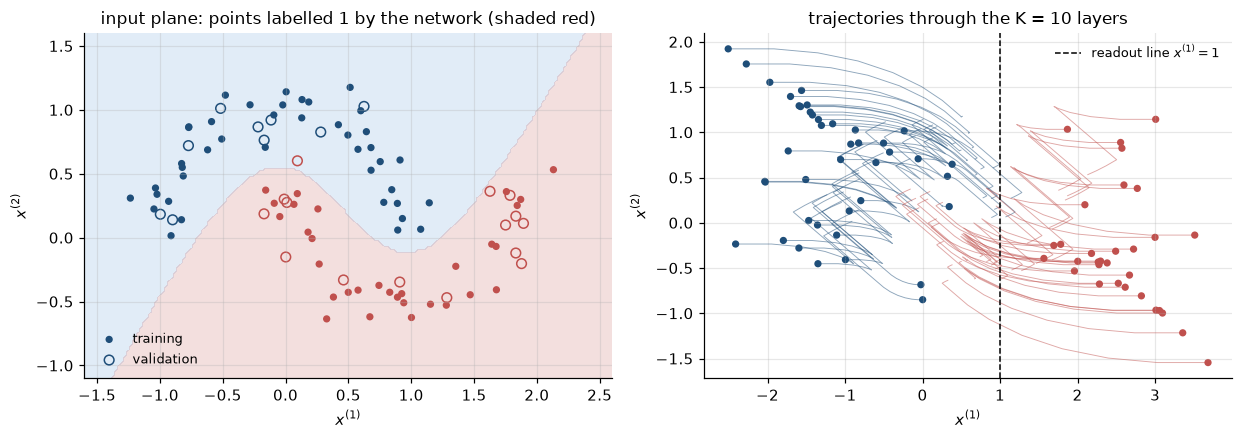

In [4]:
depths, alphas = [5, 10, 20], [0.0, 1e-3, 1e-2, 1e-1]
train_counts = {}
best, models, table = select_residual_classifier(X_tr, y_tr, X_val, y_val, depths, alphas, P=8, T=2.0, n_steps=1000,
                                                 eta=0.05, scale=4.0, counts=train_counts)     # frozen protocol, section 13
print("   K    alpha    train loss   train acc.   validation loss   validation acc.")
for (K, alpha), row in table.items():
    mark = "  <- selected" if (K, alpha) == best else ""
    print(f"{K:4d}  {alpha:7.0e}   {row['train loss']:10.4f}   {row['train accuracy']:9.3f}   "
          f"{row['validation loss']:15.4f}   {row['validation accuracy']:15.3f}{mark}")
Theta13, h13 = models[best]
print(f"training cost of the whole grid ({len(table)} trainings x 1000 Adam steps): {train_counts['field']:,} field evaluations and "
      f"{train_counts['vjp']:,} vector-Jacobian products, i.e. {8 * (train_counts['field'] + train_counts['vjp']):,} neuron evaluations")
protocol13 = {"stream keys": stream_keys, "train indices": train6, "validation indices": val6,
              "selected (K, alpha)": best, "validation": table[best],
              "final evaluation": "pending: joint 13-14 evaluation, applied in notebook 14 (protocol section 13-14)"}

g1, g2 = np.meshgrid(np.linspace(-1.6, 2.6, 170), np.linspace(-1.1, 1.6, 120))
traj_grid = euler_flow(np.column_stack([g1.ravel(), g2.ravel()]), Theta13, h13)
region = readout_label(traj_grid[-1]).reshape(g1.shape)
traj = euler_flow(X_tr, Theta13, h13)

# Is each layer x -> x + h f(x, theta_k) invertible? Sufficient: h ||W_k|| ||A_k|| < 1 (as in DEEPER LOOK 8).
# Necessary for a local orientation-preserving diffeomorphism: det(I + h D_x f) > 0 along the trajectories.
W13, A13, b13 = Theta13
step_lip = np.array([h13 * np.linalg.norm(W, 2) * np.linalg.norm(A, 2) for W, A in zip(W13, A13)])
det_min = np.inf
for k in range(len(b13)):
    S = 1 - np.tanh(traj_grid[k] @ A13[k].T + b13[k]) ** 2                     # sigma'(z) at every grid trajectory
    Jac = np.eye(2) + h13 * np.einsum("dp,np,pe->nde", W13[k], S, A13[k])
    det_min = min(det_min, (Jac[:, 0, 0] * Jac[:, 1, 1] - Jac[:, 0, 1] * Jac[:, 1, 0]).min())
print("h ||W_k|| ||A_k|| per layer:", step_lip.round(2))
print(f"smallest det(I + h D_x f) over the layers and the plotted region: {det_min:.4f}")
colors = np.where(y_tr == 1, COLORS["control"], COLORS["state"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.1))
ax1.contourf(g1, g2, region, levels=[-0.5, 0.5, 1.5], colors=[COLORS["state2"], COLORS["control"]], alpha=0.18)
ax1.scatter(X_tr[:, 0], X_tr[:, 1], c=colors, s=14, label="training")
ax1.scatter(X_val[:, 0], X_val[:, 1], facecolors="none", edgecolors=np.where(y_val == 1, COLORS["control"], COLORS["state"]),
            s=40, label="validation")
ax1.set_title("input plane: points labelled 1 by the network (shaded red)"); ax1.legend(fontsize=8.5, loc="lower left")
for n in range(len(X_tr)):
    ax2.plot(traj[:, n, 0], traj[:, n, 1], color=colors[n], lw=0.6, alpha=0.5)
ax2.scatter(traj[-1, :, 0], traj[-1, :, 1], c=colors, s=14)
ax2.axvline(1.0, color="black", lw=1, ls="--", label=r"readout line $x^{(1)}=1$")
ax2.set_title(f"trajectories through the K = {best[0]} layers"); ax2.legend(fontsize=8.5)
for ax in (ax1, ax2):
    ax.set_xlabel("$x^{(1)}$"); ax.set_ylabel("$x^{(2)}$")
plt.tight_layout(); plt.show()

**Figure 3.** The residual classifier chosen on validation data. *Left:* the input plane, shaded where the network predicts label $1$ (the preimage of $\Omega_1$ under the network map), with the training points (filled) and validation points (open), coloured by their true labels. *Right:* the trajectories of the training points through the layers, and the readout line $x^{(1)}=1$.

*Interpretation (answer to the prediction).* The validation choice is printed in the table. In this run, without regularization the training loss is driven to almost zero but the validation loss is larger: the logistic loss rewards ever more confident, larger controls, and a moderate control cost does better on validation, which is what the choice reflects. On the right the network pulls the moons apart and pushes them to the two sides of the line; the shaded region on the left is the preimage of a half-plane. The single validation error printed (one point of 24) is a point of the lower moon near its tip, which reaches into the hollow of the upper moon. **The trained network is not guaranteed to be a flow.** One layer has $h\|W_k\|\|A_k\|>1$ (printed), and the Jacobian determinant of a step becomes slightly negative somewhere in the plotted region. There, that layer folds the plane, which no flow of an ODE can do; the zig-zags of some trajectories show the large steps. Training did not ask for small steps, and nothing in the protocol enforced them: this is the remark of §1 that a trained ResNet need not be a discretized ODE. How well this classifier does on *new* observations is exactly what has not yet been measured: the joint evaluation is pending.

## 6. Control ↔ ML
`CORE`

- **Residual network = Euler scheme of a controlled ODE.** **DIRECT CONNECTION** (p. 327). Layers are time steps, parameters are controls, a forward pass is a trajectory. The approximation statement holds at a fixed horizon, under (H1)–(H2).
- **Backpropagation = the discrete adjoint.** **DIRECT CONNECTION** (p. 53; pp. 193–196; notebook 07). The same state–adjoint–gradient structure, exact for the discrete cost.
- **$L^2$ regularization of the parameters = quadratic control cost.** **DIRECT CONNECTION** (p. 328). The term $\alpha\int\|(a,w,b)\|^2$ is the $L^2$ control cost of notebooks 02–08 (as a penalty in the loss; decoupled weight decay, as in AdamW, is a different update, §3), and without it the horizon can be absorbed into the size of the controls (p. 338).
- **Classification = simultaneous control.** **DIRECT CONNECTION** (p. 336). One control for all data points. [Notebook 14](14_classification_as_simultaneous_control.ipynb) constructs such controls explicitly instead of training them.
- **Depth and long horizons.** **MATHEMATICAL ANALOGY** with notebook 08. Adding layers at a fixed step is a long-horizon problem, the setting where turnpike phenomena are studied (RESEARCH WINDOW §9). It is not a theorem about trained networks.

## 7. Common misconceptions
`CORE`

**"A deeper ResNet is always a finer discretization of a neural ODE."** Only if the horizon is fixed and the layers sample one control. Adding layers at a fixed step lengthens the horizon instead (§1, Figure 1), and a trained network's layers need not vary regularly at all.

**"Backpropagation is a different algorithm from the adjoint method."** It is the discrete adjoint: the same recursion, exact for the discrete cost (§4).

**"The gradient of the discretized cost is the discretization of the continuous gradient."** Not necessarily. It depends on how the continuous adjoint is discretized: a compatible discretization reproduces the discrete adjoint exactly, while the natural choice of DEEPER LOOK §8 differs from it, by an amount observed to be of order $h$ in our example. Optimizing the discrete network needs the gradient of the discrete cost.

**"Finite differences are a reliable way to get gradients."** They cost $2|\Theta|$ forward passes, and in our experiment they were accurate to about $10^{-10}$ at the best $\varepsilon$, limited by truncation for large $\varepsilon$ and by rounding for small $\varepsilon$ (Figure 2). They are a *test* of the gradient, not a way to compute it.

**"The horizon $T$ is a hyperparameter like any other."** At a fixed number of layers and without a control cost it can be absorbed into the weights (§1).

**"A training accuracy of 100% means the classifier is good."** It says nothing about new observations; that is what the frozen final evaluation is for (§5).

## 8. The continuous adjoint, and order preservation in one dimension
`DEEPER LOOK`

**Differentiate, then discretize.** For the continuous problem $x'=f(x,\theta(t))$ with cost $\frac1N\sum_n\big[\Phi_n(x^n(T))+\int_0^T\ell_n(x^n)dt\big]+\alpha\int_0^T|\theta|^2dt$, the same Lagrangian argument gives the **continuous adjoint system**
$$
-p^{n\,\prime}(t)=D_xf(x^n(t),\theta(t))^{\top}p^n(t)+\tfrac1N\nabla\ell_n(x^n(t)),\qquad p^n(T)=\tfrac1N\nabla\Phi_n(x^n(T)),
$$
and the gradient $\nabla_{\theta(t)}J=\sum_nD_\theta f(x^n,\theta)^\top p^n+2\alpha\theta(t)$, the structure $-\varphi'=A^*\varphi$, $\nabla J=u+B^*\varphi$ of notebook 07. One can discretize this system instead of differentiating the discrete one. A natural choice integrates the adjoint backward by explicit Euler from $t_{k+1}$ to $t_k$, with the Jacobian at $x_{k+1}$, and uses $p_k$ in the gradient on $[t_k,t_{k+1})$ (`continuous_adjoint_gradient`). Both gradients converge to the gradient of the continuous problem as $h\to0$, but for this choice **they are not equal**: the continuous version is not the exact gradient of the discrete cost. A compatible discretization, one that reproduces the backward recursion of §4, would coincide with it. In the example below their relative difference, in Euclidean norm, is observed to decrease like $h$. A theoretical bound would naturally be an absolute one, of order $h$ for smooth data and a fixed parametrization of the controls. A relative statement also needs a reference gradient bounded away from zero: near a vanishing gradient the relative error can be undefined or lose this order. The cell below measures it for a piecewise-constant control with four pieces, refined at fixed horizon; the gradients are taken with respect to the four piece values, so that they can be compared across meshes.

     h      |g_disc - g_cont| / |g_disc|   discrete vs central diff.   continuous vs central diff.
 0.50000                  5.671e-01                     1.0e-10                     7.047e-01
 0.25000                  2.702e-01                     2.8e-11                     3.290e-01
 0.12500                  1.308e-01                     3.5e-11                     1.613e-01
 0.06250                  6.427e-02                     2.4e-11                     8.052e-02
 0.03125                  3.186e-02                     8.1e-14                     4.033e-02
 0.01562                  1.586e-02                     8.8e-11                     2.019e-02
 0.00781                  7.912e-03                     1.5e-12                     1.011e-02


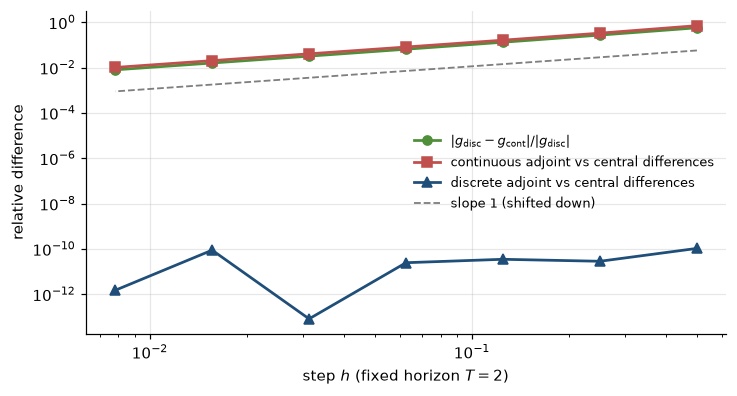

In [5]:
v_pieces = tuple(streams["dev"].normal(size=p.shape) for p in pieces_fix)       # one direction in the piece values
Phi_run, dPhi_run = Phi(y_tr), dPhi(y_tr)
rows = []
for s in (1, 2, 4, 8, 16, 32, 64):
    Th, h = piecewise_constant(pieces_fix, s), T_fix / (M * s)
    g_disc = sum_over_pieces(discrete_adjoint(X_tr, Th, h, dPhi(y_tr), dPhi_run, 0.01)[0], s)
    g_cont = sum_over_pieces(continuous_adjoint_gradient(X_tr, Th, h, dPhi(y_tr), dPhi_run, 0.01), s)
    J = lambda P_: objective(X_tr, piecewise_constant(P_, s), h, Phi(y_tr), Phi_run, 0.01)
    e = 1e-5
    central = (J(tuple(p + e * d for p, d in zip(pieces_fix, v_pieces))) - J(tuple(p - e * d for p, d in zip(pieces_fix, v_pieces)))) / (2 * e)
    dot = lambda g: sum(np.sum(a * b) for a, b in zip(g, v_pieces))
    rows.append((h, np.linalg.norm(pack(g_disc) - pack(g_cont)) / np.linalg.norm(pack(g_disc)),
                 abs(dot(g_disc) - central) / abs(central), abs(dot(g_cont) - central) / abs(central)))
rows = np.array(rows)
print("     h      |g_disc - g_cont| / |g_disc|   discrete vs central diff.   continuous vs central diff.")
for r in rows:
    print(f"{r[0]:8.5f}   {r[1]:24.3e}   {r[2]:25.1e}   {r[3]:27.3e}")
fig, ax = plt.subplots(figsize=(6.8, 3.7))
ax.loglog(rows[:, 0], rows[:, 1], "o-", color=COLORS["adjoint"], label=r"$|g_{\rm disc}-g_{\rm cont}|/|g_{\rm disc}|$")
ax.loglog(rows[:, 0], rows[:, 3], "s-", color=COLORS["control"], label="continuous adjoint vs central differences")
ax.loglog(rows[:, 0], np.maximum(rows[:, 2], 1e-16), "^-", color=COLORS["state"], label="discrete adjoint vs central differences")
slope_guide(ax, rows[:, 0], 0.1 * rows[0, 1], 1, "slope 1 (shifted down)")
ax.set_xlabel("step $h$ (fixed horizon $T=2$)"); ax.set_ylabel("relative difference"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Figure 4.** Discretize-then-differentiate against differentiate-then-discretize, for the four piece values of the fixed control of Laboratory 1 and the cost of Laboratory 2 (ii), as $h$ is refined at $T=2$. Shown: the relative difference between the two gradients, and the discrepancy of each with central differences of the *discrete* cost along one direction.

*Interpretation.* The discrete adjoint agrees with central differences of the discrete cost to the accuracy of the check at every $h$, because it is the exact gradient of that cost. The discretized continuous adjoint is off by an amount that decreases like $h$, as does its distance to the discrete gradient. Both converge to the gradient of the continuous problem, but only one of them is the gradient of the function that is actually being minimized. For a gradient method with a fixed mesh this matters: with an inexact gradient, the iteration can stall or wander at the level of the $O(h)$ error.

**Order preservation in one dimension.** For a scalar ODE $x'=f(x,\theta(t))$ with (H1), two solutions with $x(0)<y(0)$ satisfy $x(t)<y(t)$ for all $t$: if they met, uniqueness of solutions would force them to coincide forever, contradicting $x(0)<y(0)$. **The exact flow of a scalar neural ODE preserves order**, so no one-dimensional neural ODE can map $0<1$ to $1>0$, whatever the control (this restriction reappears in notebook 14). Euler inherits the property **only under a step condition**:
$$
x_{k+1}-y_{k+1}=(x_k-y_k)+h\big(f(x_k,\theta_k)-f(y_k,\theta_k)\big)\le(1+hL_f)(x_k-y_k)\quad\text{and}\quad\ge(1-hL_f)(x_k-y_k)
$$
when $x_k>y_k$, so the order is preserved if $hL_f<1$. With a large step, one Euler step of a contracting field can overshoot and swap two points. The cell below takes the neuron $f(x)=-3\tanh(x)$, so $L_f=3$, and the points $0.1<0.2$.

In [6]:
f_1d = lambda x: field(x[:, None], np.array([[-3.0]]), np.array([[1.0]]), np.array([0.0]))[:, 0]   # -3 tanh(x)
pair = np.array([0.1, 0.2])
for h in (0.25, 1.0):
    after = pair + h * f_1d(pair)
    print(f"h = {h:4.2f} (h L_f = {3 * h:4.2f}): {pair} -> {after}   order preserved: {bool(after[0] < after[1])}")

h = 0.25 (h L_f = 0.75): [0.1 0.2] -> [0.0252 0.052 ]   order preserved: True
h = 1.00 (h L_f = 3.00): [0.1 0.2] -> [-0.199  -0.3921]   order preserved: False


## 9. Turnpike and momentum: two research directions
`RESEARCH WINDOW`

**Turnpike for deep residual networks.** Training with a running cost on a long horizon, the "more layers at a fixed step" reading of §1, is a long-horizon optimal control problem. The slides cite *Turnpike in optimal control of PDEs, ResNets, and beyond* (Geshkovski–Zuazua, *Acta Numerica* 2022; p. 331), and link autonomous, very wide neural fields to turnpike theory (p. 354). The results of notebook 08 were proved for linear-quadratic problems with controllability assumptions. For neural ODEs, turnpike-type statements require specific hypotheses on the cost and the dynamics, and **no universal theorem says that a trained deep network has a turnpike**. What can be observed in experiments, and what has been proved under which assumptions, must be kept apart.

**Momentum neural ODEs** (p. 362) replace $x'=f$ by the second-order system $x''=w(t)\sigma(a(t)\cdot x+b(t))$, the continuous analogue of momentum in optimization (notebook 11). The slides state the *same capacity for simultaneous control, with $O(N)$ neurons*, and two advantages: memory, and the fact that *two points can share the same position*. The state is now $(x,x')$, so trajectories may cross in position space without contradicting uniqueness, and the one-dimensional order obstruction of §8 disappears (Exercise 6). We transcribe these statements; their precise hypotheses are in the cited works, not in the slides, and they are not proved here.

The slides' list of perspectives (p. 384) also includes width versus depth and relaxed (measure-valued) neural ODEs, which return in notebook 14.

## 10. What you should remember
`CORE`

1. A residual network $x_{k+1}=x_k+hf(x_k,\theta_k)$ is the forward Euler scheme of a controlled ODE; parameters are controls and inputs are initial states.
2. Refining $h$ at a fixed horizon approximates one flow map with error $O(h)$, under a Lipschitz condition in the state and jumps of the control on the mesh. Adding layers at a fixed step lengthens the horizon instead.
3. At a fixed number of layers and without a control cost, the horizon can be absorbed into the weights.
4. Training is simultaneous optimal control: one control for all samples, data terms averaged, regularization counted once.
5. The discrete adjoint gives the exact gradient of the discrete cost at the price of one forward and one backward pass; it is backpropagation.
6. The discretization of the continuous adjoint used in §8 gives a different gradient, observed to be about $O(h)$ away in the example; compatible discretizations coincide with the discrete adjoint.
7. Validation chooses the depth and the control cost; only a frozen final evaluation on new observations measures generalization. For the classifier of this notebook it is still pending.

## 11. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (where is $h$?)** · `FIRST PASS`. A ResNet is written without a step size, $x_{k+1}=x_k+g(x_k,\theta_k)$, $k=0,\dots,K-1$, with $g(x,\theta)=W\sigma(Ax+b)$. (a) For a chosen horizon $T$, write it as an Euler scheme $x_{k+1}=x_k+hf(x_k,\theta_k)$: what are $h$ and $f$? (b) Someone doubles the number of layers by repeating every layer twice, without changing the weights. Which of the two readings of §1 is this, and what happens to $T$ if $f$ is kept? (c) What must be done to the weights so that the doubled network approximates the *same* flow map?

**Exercise 2 ★★ (the adjoint by hand)** · `FIRST PASS`. Consider the scalar linear ResNet $x_{k+1}=(1+h\theta_k)x_k$ with $\theta_k\in\mathbb R$, one sample $x_0\ne0$, and $J=\frac12x_K^2+\alpha h\sum_k\theta_k^2$. (a) Compute $\partial J/\partial\theta_k$ directly from $x_K=x_0\prod_j(1+h\theta_j)$. (b) Write the adjoint recursion of §4 for this case and show that it gives the same result. (c) Check numerically for $K=5$.

**Exercise 3 ★★ (order in one dimension)** · `STANDARD`. (a) Prove that one Euler step of a scalar field with Lipschitz constant $L_f$ preserves the strict order of two points when $hL_f<1$. (b) Show that the condition is sharp: for $f(x)=-cx$ ($c>0$), find the steps $h$ for which the order of two points is reversed after one step, and the step for which they collide. (c) Why can no choice of control make the *exact* flow of a scalar neural ODE reverse the order of two inputs, while a ResNet with large steps can?

**Exercise 4 ★★ (the price of a gradient)** · `STANDARD`. For the classifier selected in §5: (a) compute $|\Theta|$ and the number of field evaluations needed by one central-difference gradient on the 72 training points; (b) compare with the field evaluations plus vector–Jacobian products of one adjoint gradient, and with the whole training run of 1000 Adam steps; (c) where in the adjoint computation does the regularization enter, and what would go wrong if it were added inside the per-sample terminal cost without the average?

**Exercise 5 ★★★ (a second-order scheme)** · `ADVANCED`. Heun's method replaces the Euler step by $\tilde x=x_k+hf(x_k,\theta_k)$, $x_{k+1}=x_k+\frac h2\big(f(x_k,\theta_k)+f(\tilde x,\theta_k)\big)$. (a) Implement it for the fixed control of Laboratory 1 (jumps on the mesh) and measure the observed order on nested meshes against the same reference. (b) Explain why the order would drop if a jump of the control fell inside a step, while Euler's order would not.

In [7]:
# TODO: student exercise (Exercise 5)
# Same signature as euler_flow; use theta_k for both stages of step k.

def heun_flow(X0, Theta, h):
    ...  # your code here
    return None

**Exercise 6 ★★★ (momentum: two points can swap)** · `ADVANCED`. Consider the momentum neural ODE $x''=w\sigma(ax+b)$ in one dimension with the constant control $w=-1$, $a=1$, $b=0$, $\sigma=\tanh$, i.e. $x''=-\tanh x$, starting at rest. Discretize it as the momentum ResNet $x_{k+1}=x_k+hv_k$, $v_{k+1}=v_k+hf(x_{k+1})$ with $h=0.01$. (a) Starting from $x_0=0.5$ and $x_0=1$, find a time at which their order is reversed. (b) Why does this not contradict DEEPER LOOK §8? (c) Relate this to the statement of p. 362 that *two points can share the same position*.

## Where are we going?
`CORE`

In this notebook the control of a residual network was *trained*: gradient descent with exact adjoint gradients. [Notebook 14](14_classification_as_simultaneous_control.ipynb) asks the control-theoretic question behind the classifier of §5: can a neural ODE with ReLU activation steer *every* training point into the region of its label? It answers it with *constructed* piecewise-constant controls whose switches can be counted. It also runs the joint final evaluation registered here.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 ResNet as Euler scheme | 327, 53, 337, 338, 339 | NODE, ResNet, shallow network; ResNet (He et al.) and backpropagation in the history; NODEs in action; $T$ absorbed into $\|w\|$; flow map, piecewise-constant controls, one discontinuity per layer |
| §2 Euler's error | — | Pedagogical addition (classical proof); Laboratory 1 and Figure 1 |
| §3 Training as control | 328, 336 | Standard computational practice (empirical risk along trajectories $+\,\alpha\int\|(a,w,b)\|^2$); simultaneous / ensemble control |
| §4 Discrete adjoint | 193–196, 53 | The adjoint method; backpropagation as reverse-mode automatic differentiation |
| §5 E6 classifier | 359, 328 | Label regions $\Omega_1=\{x^{(1)}>1\}$, $\Omega_0=\{x^{(1)}<1\}$; regularization |
| §6 Control ↔ ML | 327, 328, 336, 338 | As in §§1–5 |
| §8 Continuous adjoint, 1-D order (DEEPER LOOK) | 193–196 | Adjoint method (continuous version via notebook 07); the order argument is a pedagogical addition |
| §9 Turnpike, momentum (RESEARCH WINDOW) | 331, 354, 362, 384 | Turnpike for ResNets (cited work); link of wide autonomous fields to turnpike; momentum and relaxed neural ODEs; perspectives |

The source-map rows also record the pedagogical additions:
- the Euler error Proposition and its proof, with Laboratory 1;
- the discrete-adjoint derivation with sample averages and regularization;
- the gradient check (Figure 2);
- the E6 classifier with fixed readout and its frozen protocol (Figure 3);
- the continuous-versus-discrete comparison (Figure 4).

They also record the remarks:
- the horizon is absorbed into the weights only at a fixed number of layers and without a control cost;
- the slides' $L$ (layers) against $L_f$ (Lipschitz constant).